In [2]:
import pandas as pd
import numpy as np 

df_california = pd.read_csv('california_preprocessed_v2.csv')
df_arkansas = pd.read_csv('arkansas_preprocessed_v2.csv')

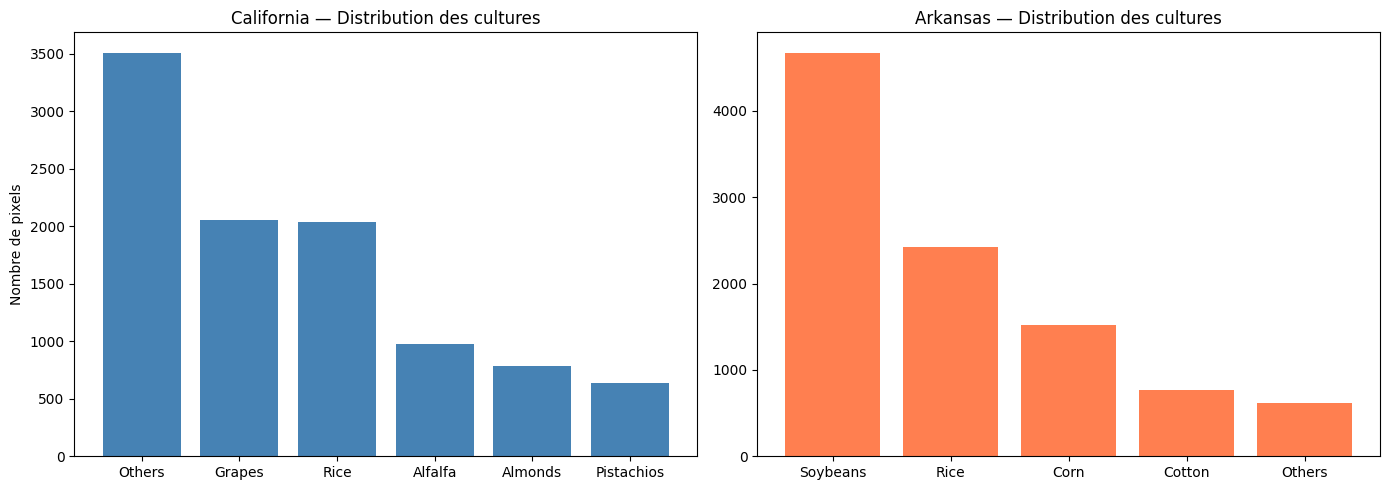

In [3]:
import matplotlib.pyplot as plt

# Mapping des classes
mapping_ca = {3: 'Rice', 36: 'Alfalfa', 69: 'Grapes', 75: 'Almonds', 76: 'Pistachios', 176: 'Others'}
mapping_ar = {1: 'Soybeans', 2: 'Cotton', 3: 'Rice', 5: 'Corn', 176: 'Others'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# California
counts_ca = df_california['cropland'].map(mapping_ca).value_counts()
axes[0].bar(counts_ca.index, counts_ca.values, color='steelblue')
axes[0].set_title('California — Distribution des cultures')
axes[0].set_ylabel('Nombre de pixels')

# Arkansas
counts_ar = df_arkansas['cropland'].map(mapping_ar).value_counts()
axes[1].bar(counts_ar.index, counts_ar.values, color='coral')
axes[1].set_title('Arkansas — Distribution des cultures')

plt.tight_layout()
plt.savefig('distribution_classes.png', dpi=150)
plt.show()

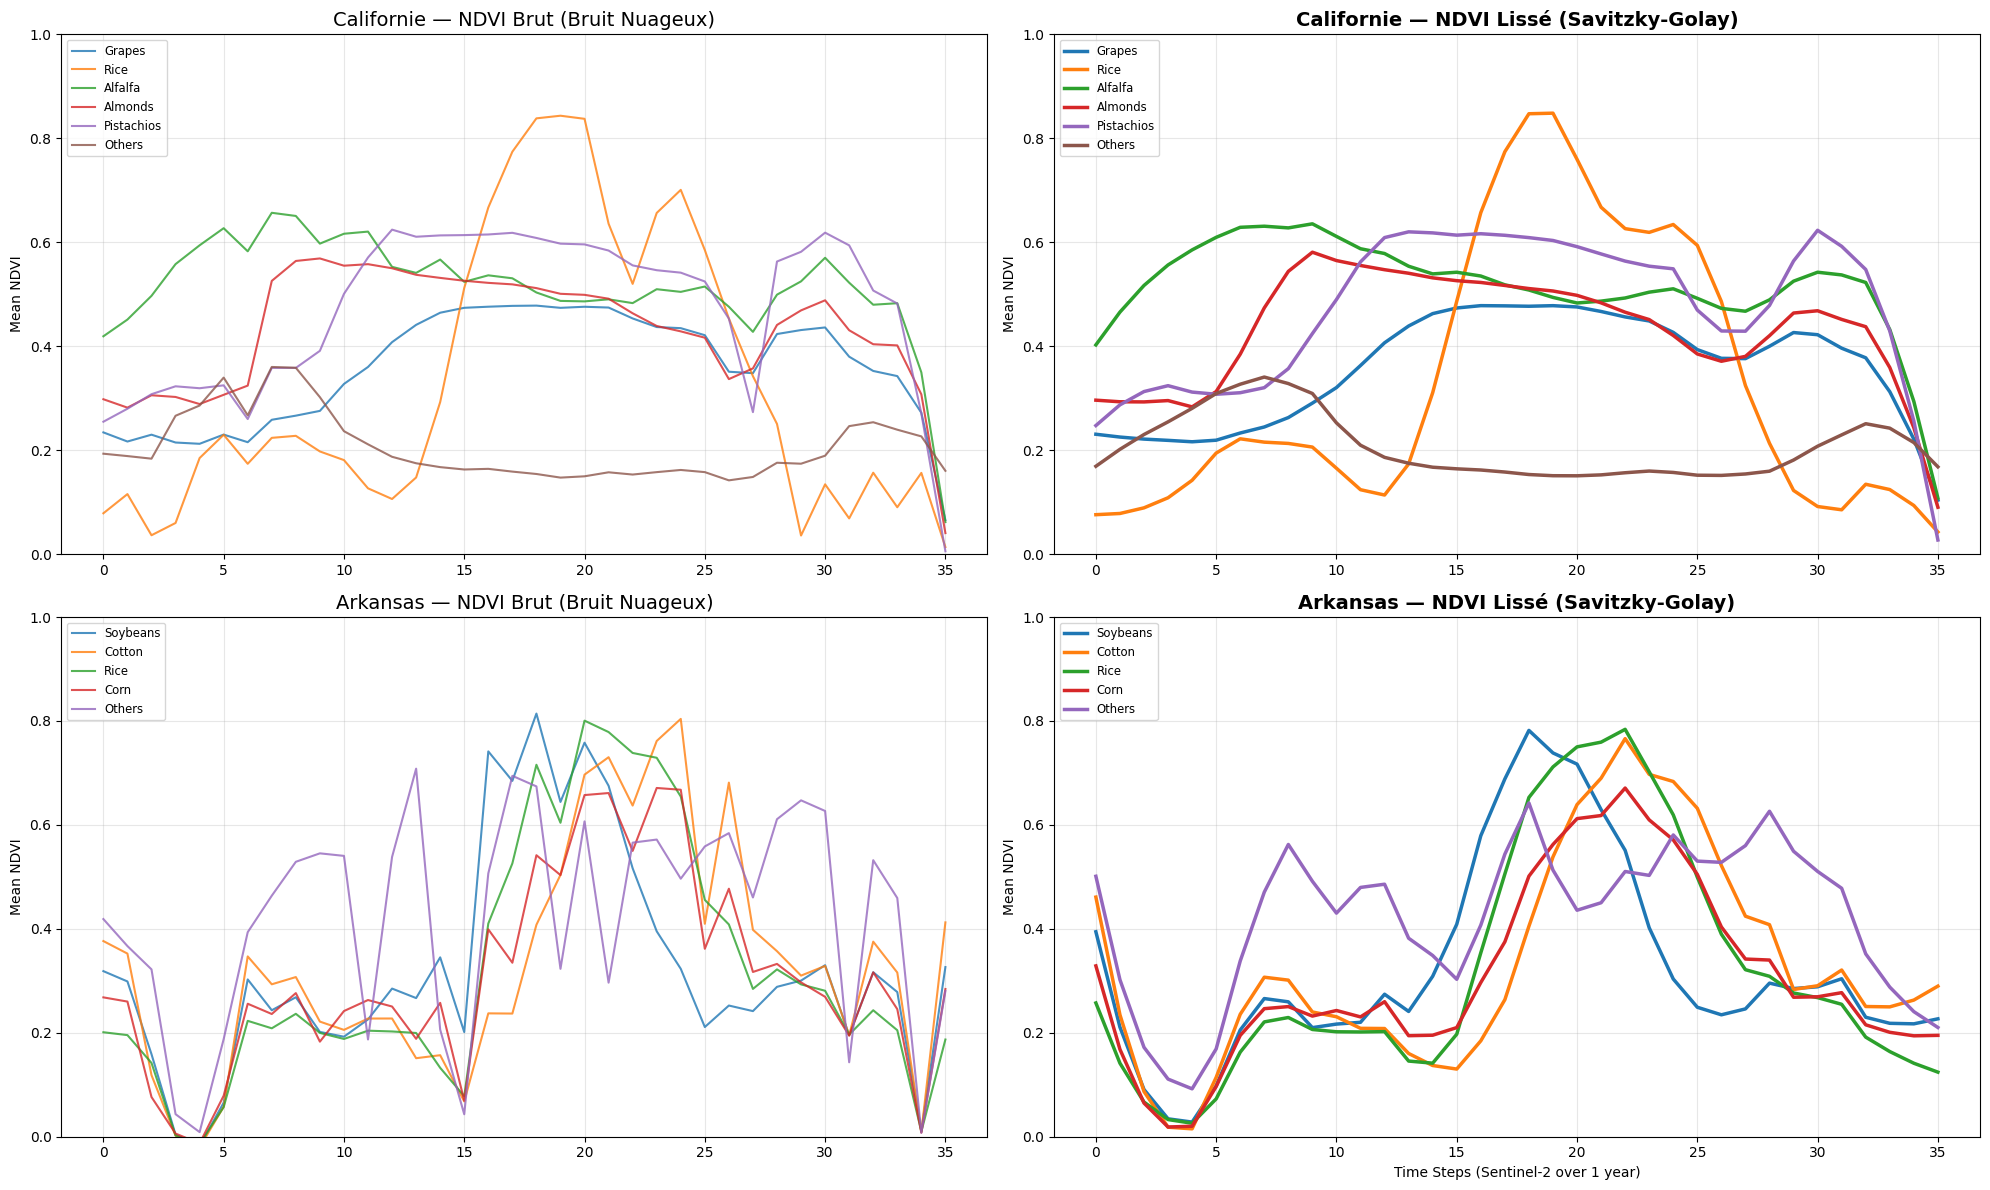

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import savgol_filter

# 1. Configuration des axes (2 lignes pour les états, 2 colonnes pour Brut vs Lissé)
fig, axes = plt.subplots(2, 2, figsize=(20, 12))

ndvi_cols = [f'ndvi_{i}' for i in range(36)]
x = range(36)

mapping_ca = {3: 'Rice', 36: 'Alfalfa', 69: 'Grapes', 75: 'Almonds', 76: 'Pistachios', 176: 'Others'}
mapping_ar = {1: 'Soybeans', 2: 'Cotton', 3: 'Rice', 5: 'Corn', 176: 'Others'}



# Paramètres du filtre Savitzky-Golay
window = 7
poly = 2

datasets = [
    (df_california, mapping_ca, 'Californie', 0),
    (df_arkansas, mapping_ar, 'Arkansas', 1)
]

for df, mapping, state_name, row in datasets:
    for code, name in mapping.items():
        subset = df[df['cropland'] == code]
        if not subset.empty:
            mean_ndvi = subset[ndvi_cols].mean()
            
            # --- Plot Brut (Colonne 0) ---
            axes[row, 0].plot(x, mean_ndvi, label=name, alpha=0.8, linewidth=1.5)
            
            # --- Plot Lissé (Colonne 1) ---
            # Le filtre élimine les chutes brutales dues aux nuages
            smoothed = savgol_filter(mean_ndvi, window_length=window, polyorder=poly)
            axes[row, 1].plot(x, smoothed, label=name, linewidth=2.5)

    # Style des subplots
    for col in range(2):
        axes[row, col].set_ylim(0, 1)
        axes[row, col].set_ylabel('Mean NDVI')
        axes[row, col].legend(loc='upper left', fontsize='small')
        axes[row, col].grid(alpha=0.3)

    axes[row, 0].set_title(f'{state_name} — NDVI Brut (Bruit Nuageux)', fontsize=14)
    axes[row, 1].set_title(f'{state_name} — NDVI Lissé (Savitzky-Golay)', fontsize=14, fontweight='bold')

plt.xlabel('Time Steps (Sentinel-2 over 1 year)')
plt.tight_layout()
plt.show()

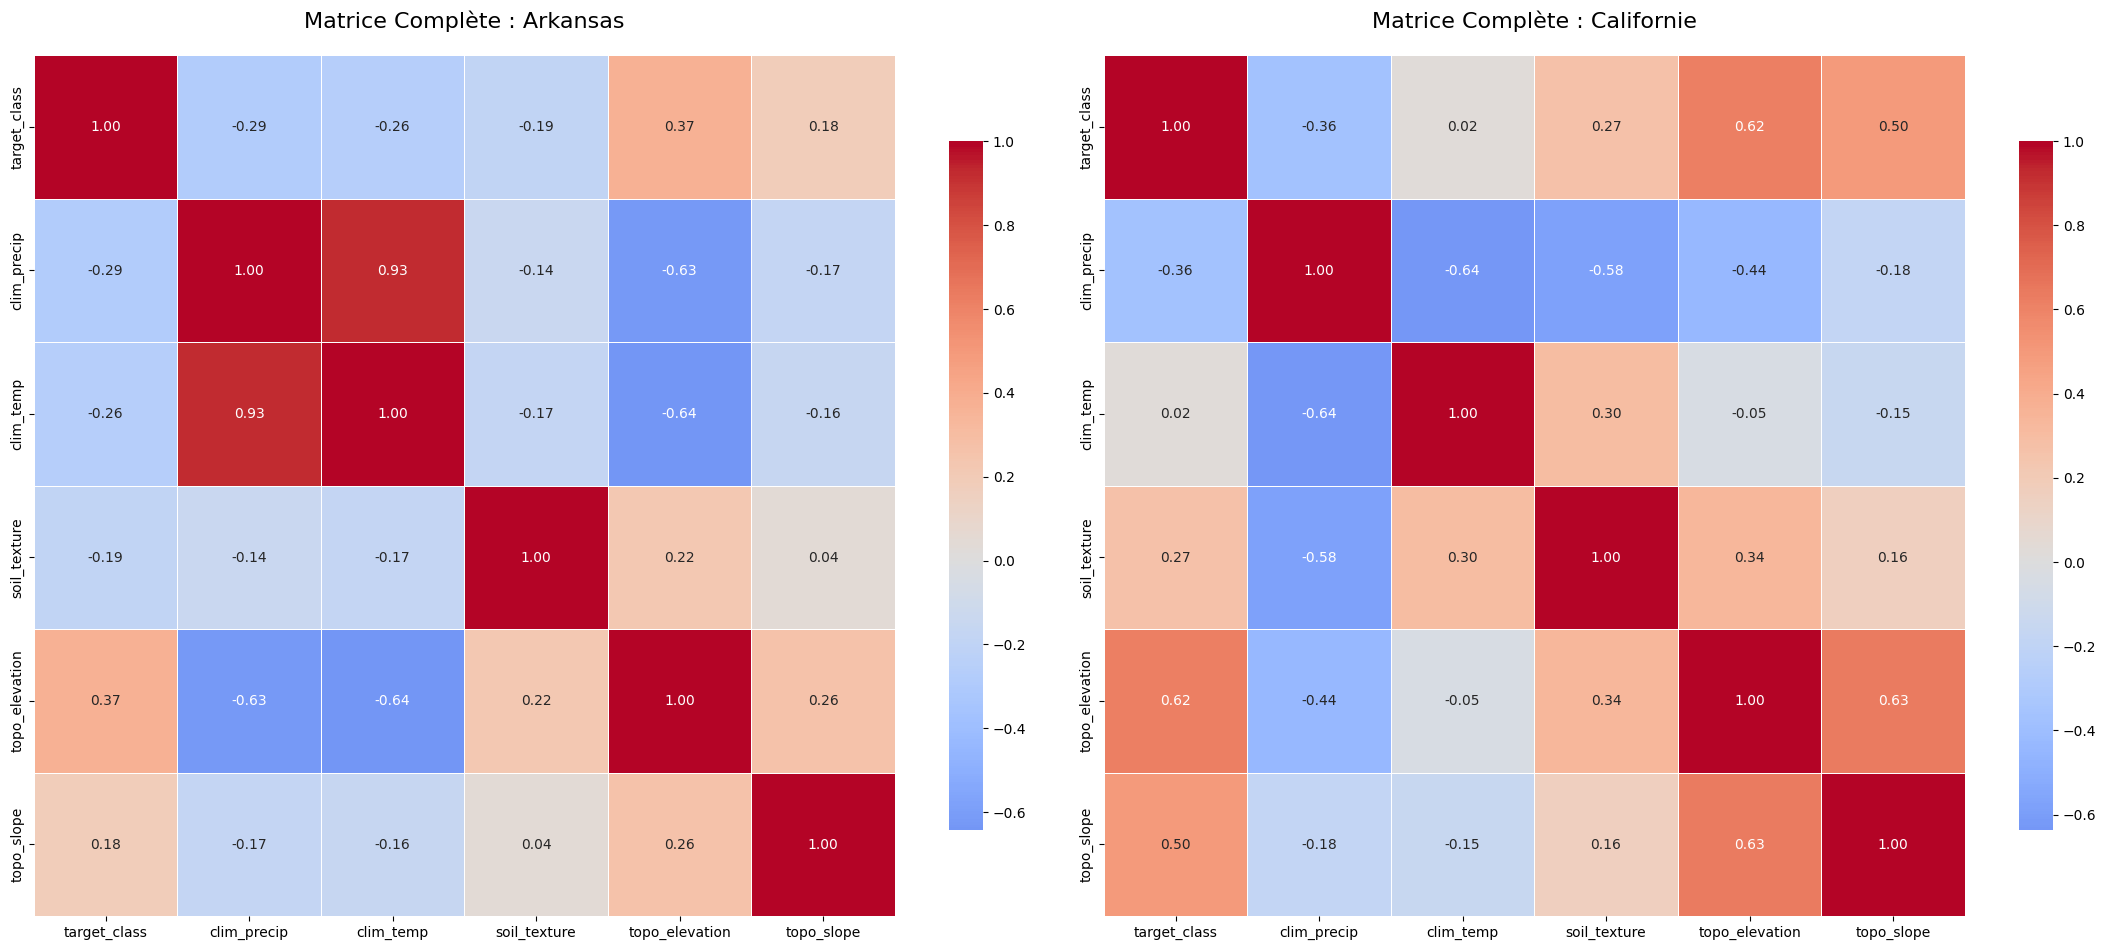

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


df_ar = pd.read_csv('arkansas_preprocessed_v2.csv') 
df_ca = pd.read_csv('california_preprocessed_v2.csv')

covars = ['target_class', 'clim_precip', 'clim_temp', 'soil_texture', 'topo_elevation', 'topo_slope']

fig, axes = plt.subplots(1, 2, figsize=(22, 9))

for i, (df, title) in enumerate([(df_ar, 'Arkansas'), (df_ca, 'Californie')]):
    
    corr = df[covars].corr()
    
    
    sns.heatmap(corr, 
                annot=True, 
                fmt=".2f", 
                cmap='coolwarm', 
                center=0,
                square=True, 
                ax=axes[i],
                linewidths=.5,
                cbar_kws={"shrink": .8})
    
    axes[i].set_title(f'Matrice Complète : {title}', fontsize=16, pad=20)

plt.tight_layout()
plt.show()